In [1]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure, color, data
from skimage.measure import label, regionprops
from skimage.feature import greycomatrix, greycoprops

ImportError: cannot import name 'greycomatrix' from 'skimage.feature' (c:\Users\Facu\Desktop\Facultad\Optativas\Procesamiento de Imagenes\TPs\TPs_PDI\.venv\Lib\site-packages\skimage\feature\__init__.py)

In [2]:
def show_images(images, titles=None):
    """Display multiple images in a grid."""
    n = len(images)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()
    
    for i in range(n):
        image = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
        axes[i].imshow(image)
        if titles:
            axes[i].set_title(titles[i])
        axes[i].axis('off')
    
    for j in range(i + 1, rows * cols):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

2. (*) Representacion por relleno de regiones. Identificar los objetos en una imagen binaria y colorear
cada region detectada. Sugerencia: scikit-image: measure.label, regionprops, label2rgb.


Regiones detectadas: 208
Región 1: área=8962.0, centro=(np.float64(37.25016737335416), np.float64(65.39511269805847))
Región 2: área=164827.0, centro=(np.float64(275.76242363205057), np.float64(328.9617781067422))
Región 3: área=17704.0, centro=(np.float64(114.60957975598735), np.float64(595.6423971983733))
Región 4: área=10.0, centro=(np.float64(13.5), np.float64(746.0))
Región 5: área=227.0, centro=(np.float64(32.519823788546255), np.float64(759.1453744493392))
Región 6: área=394.0, centro=(np.float64(29.14720812182741), np.float64(175.5482233502538))
Región 7: área=146.0, centro=(np.float64(29.65068493150685), np.float64(743.1095890410959))
Región 8: área=1.0, centro=(np.float64(28.0), np.float64(6.0))
Región 9: área=7.0, centro=(np.float64(32.42857142857143), np.float64(3.2857142857142856))
Región 10: área=1.0, centro=(np.float64(32.0), np.float64(11.0))
Región 11: área=23.0, centro=(np.float64(36.56521739130435), np.float64(730.9130434782609))
Región 12: área=2.0, centro=(np.float

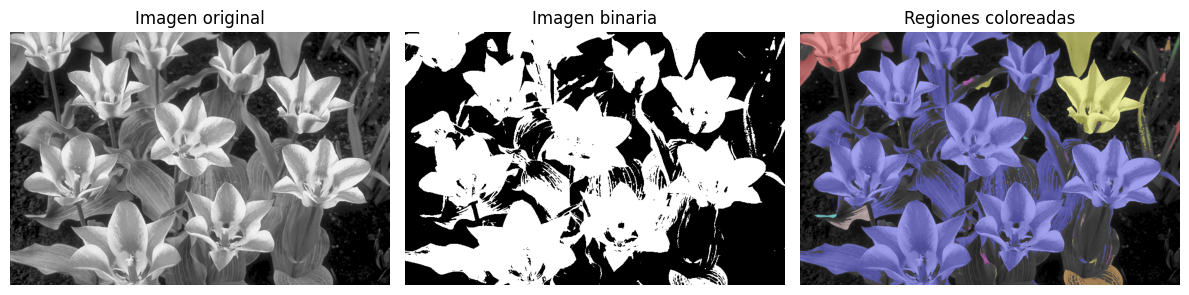

In [6]:
# Cargar imagen en escala de grises
imagen = cv2.imread('tulips.png', cv2.IMREAD_GRAYSCALE)  

# Umbral automático (por ejemplo, Otsu)
umbral = cv2.threshold(imagen, 50, 180, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[0]
imagen_binaria = imagen > umbral  # True para fondo claro, False para oscuro

# Etiquetado de componentes conectados
etiquetas = measure.label(imagen_binaria, connectivity=2)
print(f"Regiones detectadas: {etiquetas.max()}")  # No cuenta el fondo

# Convertir etiquetas a colores (colorea cada región con un color diferente)
imagen_coloreada = color.label2rgb(etiquetas, image=imagen, bg_label=0)

# También podemos obtener propiedades de cada región
regiones = measure.regionprops(etiquetas)
for i, region in enumerate(regiones):
    print(f"Región {i+1}: área={region.area}, centro={region.centroid}")

# Mostrar imágenes
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(imagen, cmap='gray')
plt.title("Imagen original")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(imagen_binaria, cmap='gray')
plt.title("Imagen binaria")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(imagen_coloreada)
plt.title("Regiones coloreadas")
plt.axis('off')

plt.tight_layout()
plt.show()


4. (*) Calculo de propiedades geometricas. Extraer area, perımetro, excentricidad y compacidad de
cada region segmentada. Sugerencia: regionprops de skimage.measure.


Región 1:
  Área: 163.0
  Perímetro: 69.66
  Excentricidad: 0.98
  Compacidad: 2.37
------------------------------
Región 2:
  Área: 27.0
  Perímetro: 22.41
  Excentricidad: 0.98
  Compacidad: 1.48
------------------------------
Región 3:
  Área: 220697.0
  Perímetro: 17849.05
  Excentricidad: 0.78
  Compacidad: 114.87
------------------------------
Región 4:
  Área: 1.0
  Perímetro: 0.00
  Excentricidad: 0.00
  Compacidad: 0.00
------------------------------
Región 5:
  Área: 1.0
  Perímetro: 0.00
  Excentricidad: 0.00
  Compacidad: 0.00
------------------------------
Región 6:
  Área: 1.0
  Perímetro: 0.00
  Excentricidad: 0.00
  Compacidad: 0.00
------------------------------
Región 7:
  Área: 1.0
  Perímetro: 0.00
  Excentricidad: 0.00
  Compacidad: 0.00
------------------------------
Región 8:
  Área: 1.0
  Perímetro: 0.00
  Excentricidad: 0.00
  Compacidad: 0.00
------------------------------
Región 9:
  Área: 1.0
  Perímetro: 0.00
  Excentricidad: 0.00
  Compacidad: 0.00
-------

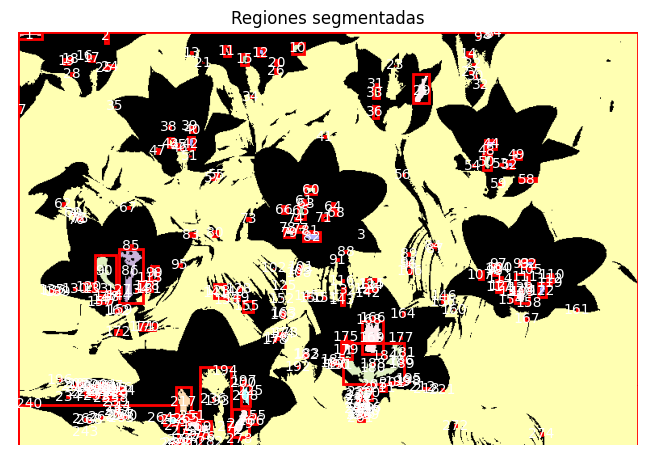

In [4]:
imagen = cv2.imread('tulips.png', cv2.IMREAD_GRAYSCALE)
_, binaria = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY_INV)

label_img = label(binaria)
imagen_etiquetada = color.label2rgb(label_img, image=binaria, bg_label=0)

props = regionprops(label_img)

for i, region in enumerate(props):
    area = region.area
    perimetro = region.perimeter
    excentricidad = region.eccentricity
    compacidad = (perimetro ** 2) / (4 * np.pi * area) if area > 0 else 0

    print(f"Región {i + 1}:")
    print(f"  Área: {area}")
    print(f"  Perímetro: {perimetro:.2f}")
    print(f"  Excentricidad: {excentricidad:.2f}")
    print(f"  Compacidad: {compacidad:.2f}")
    print("-" * 30)

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(imagen_etiquetada)

for region in props:
    y0, x0 = region.centroid
    minr, minc, maxr, maxc = region.bbox
    rect = plt.Rectangle((minc, minr), maxc - minc, maxr - minr,
                         edgecolor='red', facecolor='none', linewidth=2)
    ax.add_patch(rect)
    ax.text(x0, y0, f"{int(region.label)}", color='white', ha='center', va='center')

plt.title('Regiones segmentadas')
plt.axis('off')
plt.show()


6. (*) Descriptores de textura con GLCM. Calcular contraste, correlacion y homogeneidad de regiones
usando matrices de co-ocurrencia. skimage.feature.greycomatrix, greycoprops.


8. (*) Relacion espacial entre regiones. Determinar si las regiones estan adyacentes o si una esta contenida en otra. skimage.measure.regionprops + analisis de coordenadas / bounding boxes.